In [2]:
!pip install pandasql -q

  Preparing metadata (setup.py) ... done


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandasql import sqldf

np.random.seed(42)

n=200

data = {
    'order_id':  range(1, n+1),
    'user_id':   np.random.randint(1, 51, n),
    'category':  np.random.choice(['Electronics','Clothes','Food','Beauty'], n),
    'revenue':   np.round(np.random.normal(150, 80, n).clip(10), 2),
    'month':     np.random.choice(['Jan','Feb','Mar'], n)
}

df = pd.DataFrame(data)
df['is_paid'] = (df['revenue'] > 0).astype(int)

pysql = lambda q: sqldf(q, globals())
df.head(10)

,order_id,user_id,category,revenue,month,is_paid
0,1,39,Food,200.05,Feb,1
1,2,29,Food,81.43,Feb,1
2,3,15,Clothes,64.33,Feb,1
3,4,43,Beauty,188.60,Feb,1
4,5,8,Beauty,132.12,Jan,1
5,6,21,Beauty,207.12,Jan,1
6,7,39,Electronics,187.86,Mar,1
7,8,19,Beauty,144.17,Feb,1
8,9,23,Electronics,82.26,Mar,1
9,10,11,Clothes,28.81,Jan,1


In [5]:
query1 = """
SELECT category,
       COUNT (*) AS orders,
       ROUND(SUM(revenue), 2) AS total_revenue,
       ROUND(AVG(revenue), 2) AS avg_check
FROM df
GROUP BY category
ORDER BY total_revenue DESC
"""

pysql(query1)

,category,orders,total_revenue,avg_check
0,Beauty,65,9972.42,153.42
1,Food,46,7775.52,169.03
2,Electronics,45,6815.28,151.45
3,Clothes,44,6686.14,151.96


In [8]:
query2 = """
SELECT
       ROUND(SUM(revenue) / COUNT(DISTINCT user_id), 2) AS arpu,
       ROUND(SUM(revenue) / COUNT(DISTINCT CASE WHEN is_paid = 1 THEN user_id END), 2) AS arppu,
       COUNT(DISTINCT user_id) AS total_users,
       COUNT(DISTINCT CASE WHEN is_paid = 1 THEN user_id END)
       AS paying_users
FROM df
"""

pysql(query2)

,arpu,arppu,total_users,paying_users
0,637.74,637.74,49,49


  month  orders   revenue  avg_check
0   Jan      74  11950.14     161.49
1   Feb      68   9726.49     143.04
2   Mar      58   9572.73     165.05


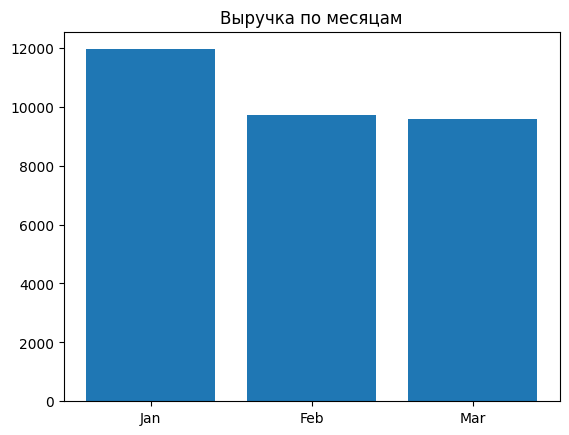

In [9]:
# SQL — выручка по месяцам
query3 = """
SELECT month,
       COUNT(*) AS orders,
       ROUND(SUM(revenue), 2) AS revenue,
       ROUND(AVG(revenue), 2) AS avg_check
FROM df
GROUP BY month
ORDER BY CASE month WHEN 'Jan' THEN 1 WHEN 'Feb' THEN 2 WHEN 'Mar' THEN 3 END
"""
df_months = pysql(query3)
print(df_months)

# График
plt.bar(df_months['month'], df_months['revenue'])
plt.title('Выручка по месяцам')
plt.show()

In [10]:
query4 = """
SELECT user_id,
       COUNT(*) AS orders,
       ROUND(SUM(revenue), 2) AS total_revenue
FROM df
GROUP BY user_id
ORDER BY total_revenue DESC
LIMIT 5
"""
pysql(query4)

,user_id,orders,total_revenue
0,44,10,1703.66
1,39,9,1683.82
2,28,7,1225.76
3,15,7,1213.52
4,42,6,1189.52


In [11]:
query5 = """
SELECT
    user_id,
    COUNT(*) AS orders,
    CASE WHEN COUNT(*) > 1 THEN 'Повторный' ELSE 'Новый' END AS customer_type
FROM df
GROUP BY user_id
"""
df_retention = pysql(query5)

repeat = len(df_retention[df_retention['customer_type'] == 'Повторный'])
new = len(df_retention[df_retention['customer_type'] == 'Новый'])
print(f'Повторные покупатели: {repeat} ({repeat/len(df_retention)*100:.0f}%)')
print(f'Новые (1 заказ): {new} ({new/len(df_retention)*100:.0f}%)')

Повторные покупатели: 45 (92%)
Новые (1 заказ): 4 (8%)


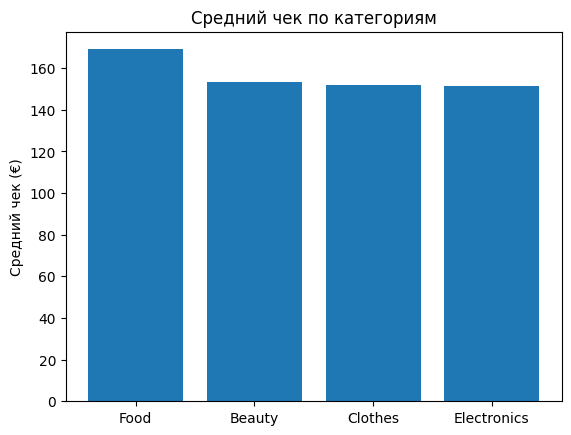

,category,avg_check
0,Food,169.03
1,Beauty,153.42
2,Clothes,151.96
3,Electronics,151.45


In [15]:
df_cat = pysql("""
    SELECT category, ROUND(AVG(revenue), 2) AS avg_check
    FROM df GROUP BY category ORDER BY avg_check DESC
""")

plt.bar(df_cat['category'], df_cat['avg_check'])
plt.title('Средний чек по категориям')
plt.ylabel('Средний чек (€)')
plt.show()

df_cat

In [13]:
query_rfm = """
SELECT
    user_id,
    COUNT(*) AS frequency,
    ROUND(SUM(revenue), 2) AS monetary,
    CASE
        WHEN COUNT(*) >= 5 AND SUM(revenue) > 700 THEN 'VIP'
        WHEN COUNT(*) >= 3 THEN 'Regular'
        ELSE 'New'
    END AS segment
FROM df
GROUP BY user_id
ORDER BY monetary DESC
LIMIT 10
"""
pysql(query_rfm)

,user_id,frequency,monetary,segment
0,44,10,1703.66,VIP
1,39,9,1683.82,VIP
2,28,7,1225.76,VIP
3,15,7,1213.52,VIP
4,42,6,1189.52,VIP
5,8,7,1177.55,VIP
6,24,8,1155.18,VIP
7,26,5,1090.64,VIP
8,45,5,992.39,VIP
9,14,6,979.64,VIP


In [16]:
print(f"""
БИЗНЕС-ВЫВОД: E-commerce анализ Q1 2024
=========================================

Общая выручка: {df['revenue'].sum():.0f}€
Всего заказов: {len(df)}
Активных пользователей: 49 из 50

Топ категория: Beauty (9 972€, 65 заказов)
Лучший месяц: Январь (11 950€, 74 заказа)

ARPU:  637.74€ — средняя выручка на пользователя
ARPPU: 637.74€ — все пользователи платящие

Топ клиент: User 44 — 10 заказов, 1703€

Рекомендации:
1. Beauty — развивать ассортимент, лидер продаж
2. Февраль и март просели — запустить акции
3. User 44, 39 — VIP программа лояльности
""")


БИЗНЕС-ВЫВОД: E-commerce анализ Q1 2024

Общая выручка: 31249€
Всего заказов: 200
Активных пользователей: 49 из 50

Топ категория: Beauty (9 972€, 65 заказов)
Лучший месяц: Январь (11 950€, 74 заказа)

ARPU:  637.74€ — средняя выручка на пользователя
ARPPU: 637.74€ — все пользователи платящие

Топ клиент: User 44 — 10 заказов, 1703€

Рекомендации:
1. Beauty — развивать ассортимент, лидер продаж
2. Февраль и март просели — запустить акции
3. User 44, 39 — VIP программа лояльности

